In [1]:
import sys
sys.path.insert(0, "..")
from src.consumers.consume import consume

from src.analysis.efficient_region.analysis import compute_efficient_region
from src.analysis.efficient_region.plot import plot_efficient_region, print_results
import os
os.chdir("..")

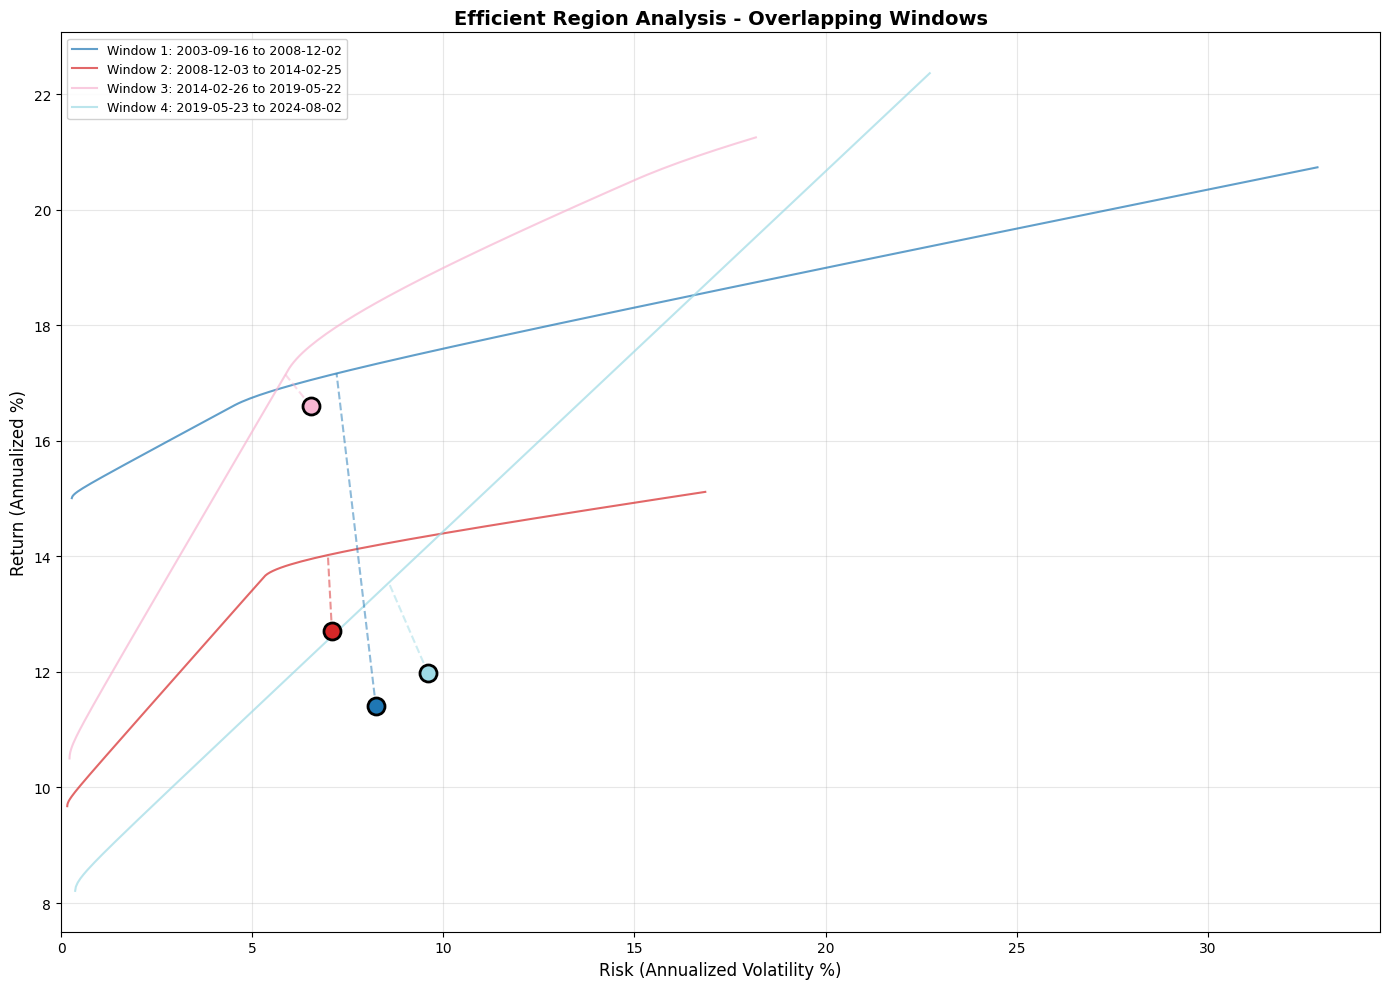

EFFICIENT REGION ANALYSIS RESULTS

Analysis Configuration:
  Requested Period:     2003-09-16 to 2024-10-24
  Window Size:          1260 days
  Independent Windows:  True
  Number of Windows:    4

TEST PORTFOLIO WEIGHTS
  imab                  50.00%
  sp500brl              25.00%
  bovespa               15.00%
  imas                  10.00%

PORTFOLIO LOSS SCORE
  Average Error Score (normalized): 0.1408

WINDOW ANALYSIS

WINDOW 1
----------------------------------------
  Period: 2003-09-16 to 2008-12-02
  Test Portfolio Performance:
    Return:        11.40%
    Volatility:     8.24%
    Variance:      67.83%²
  Distance to Frontier:        5.8522
  Portfolio Error Score:        0.3144
  Index Performance:
    bovespa               Return:    20.73%  Volatility:    32.86%
    imab                  Return:    16.54%  Volatility:     4.36%
    imas                  Return:    15.01%  Volatility:     0.28%
    sp500brl              Return:    -5.91%  Volatility:    18.66%

WINDOW 2
--

In [2]:
bovespa = consume('bovespa')
sp500brl = consume('sp500brl')
imab = consume('imab')
imas = consume('imas')

indexes = [bovespa, imab, imas, sp500brl]

test_portfolio = {
    'bovespa': 15.0,
    'imab': 50,
    'imas': 10,
    'sp500brl': 25.0
}

results = compute_efficient_region(
    indexes, 
    test_portfolio=test_portfolio,
    window_size=5 *252,
    sample_number=10,
    independent_windows=True,
    n_points=200
)

plot_efficient_region(results, 'Efficient Region Analysis - Overlapping Windows')
print_results(results)

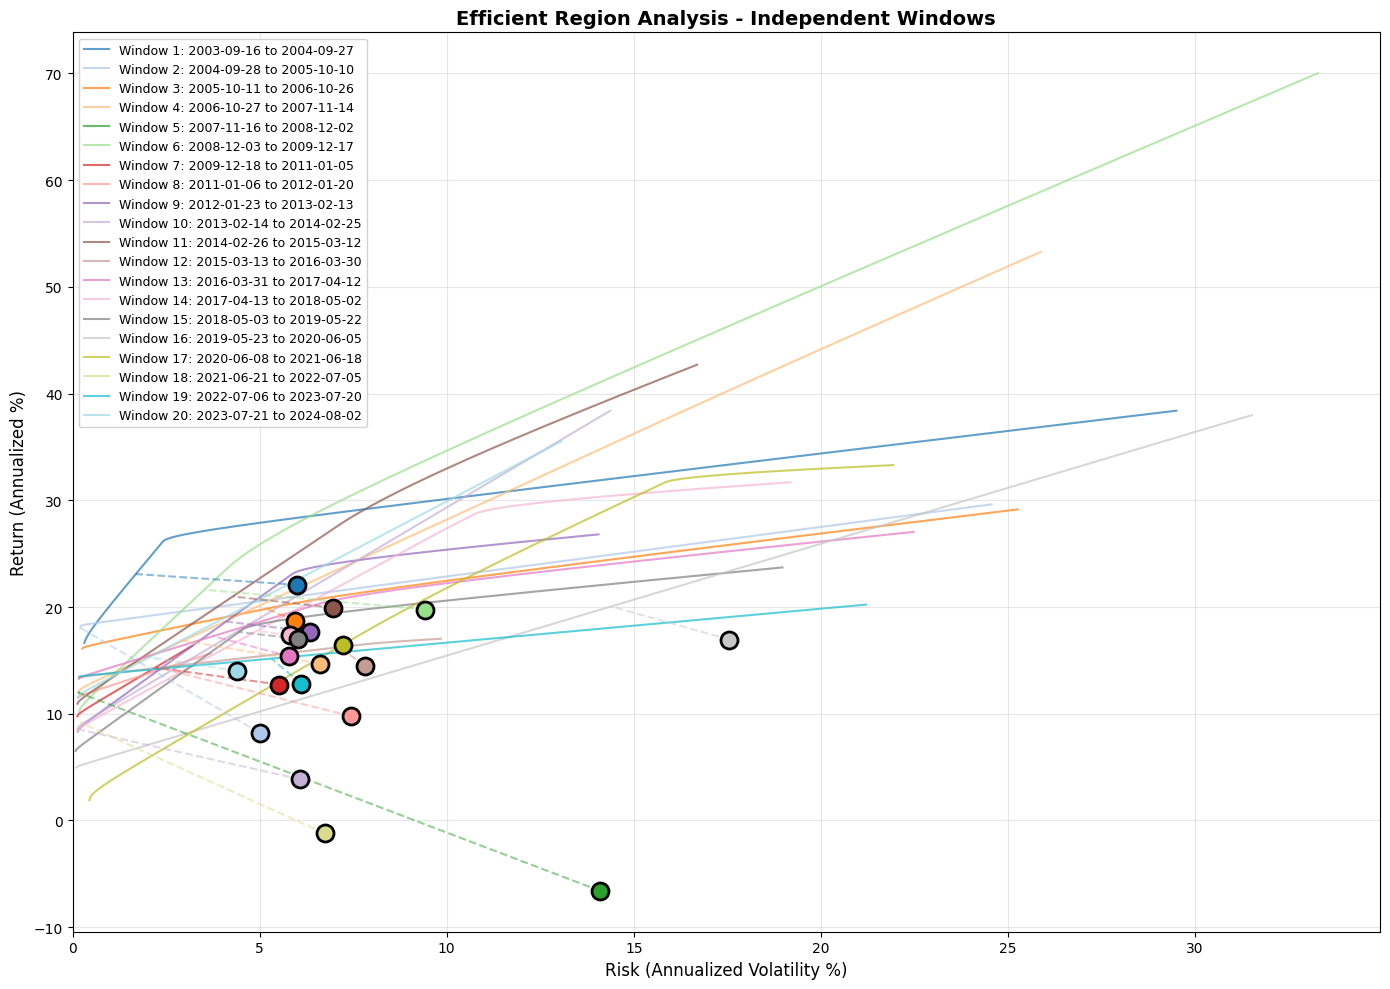

EFFICIENT REGION ANALYSIS RESULTS

Analysis Configuration:
  Requested Period:     2003-09-16 to 2024-10-24
  Window Size:          252 days
  Independent Windows:  True
  Number of Windows:    20

TEST PORTFOLIO WEIGHTS
  imab                  50.00%
  sp500brl              25.00%
  bovespa               15.00%
  imas                  10.00%

PORTFOLIO LOSS SCORE
  Average Error Score (normalized): 0.3727

WINDOW ANALYSIS

WINDOW 1
----------------------------------------
  Period: 2003-09-16 to 2004-09-27
  Test Portfolio Performance:
    Return:        22.08%
    Volatility:     6.01%
    Variance:      36.06%²
  Distance to Frontier:        4.4313
  Portfolio Error Score:        0.1914
  Index Performance:
    bovespa               Return:    38.39%  Volatility:    29.50%
    imab                  Return:    26.06%  Volatility:     2.41%
    imas                  Return:    16.64%  Volatility:     0.32%
    sp500brl              Return:     6.50%  Volatility:    13.47%

WINDOW 2
--

In [3]:
results_independent = compute_efficient_region(
    indexes, 
    test_portfolio=test_portfolio,
    window_size=252,
    sample_number=10,
    independent_windows=True,
    n_points=200
)

plot_efficient_region(results_independent, 'Efficient Region Analysis - Independent Windows')
print_results(results_independent)